# 24 — Non-negative ensemble stacking on existing out-of-fold predictions

**Read-only on all existing artifacts. No training, no Chemprop, no submission built or sent.**

## Motivation

This project's two real ensembling attempts both LOST on the real leaderboard despite
winning on cross-validation. NB10 (notebook 08's simple averages) and NB12 (notebook
11b/12's capped Caruana bagged selection) both scored macro ST-RAE 0.8299, against the
plain unensembled single model (`10c`) at 0.7138. Per-isoform, ensembling hurt CYP1A2,
CYP2D6 and CYP3A4 and was neutral-to-slightly-positive only on CYP2C9.

A top-10 entrant on this exact challenge (macro rank 10 of 146) reports the same
failure mode and names a specific structural cause: with residual correlations between
members running roughly 0.55-0.88, unconstrained ridge and elastic-net combiners
returned large *cancelling* coefficients — one member near +1.9 against another at
-0.6, and on one endpoint the best standalone model went negative, used as a
correction term rather than a predictor. Their fix — restricting the stacker to
non-negative combiners — forbids the cancellation structurally rather than penalising
it. This notebook tests whether that mechanism is present in this project's own OOF
pool, and whether a non-negative combiner does any better than what's already on
record (simple averaging, Caruana selection).

This is a **report**, not an adoption decision. Nothing here is submitted, retrained,
or recommended for adoption — Part 4 states the verdict and stops.

## Scope boundaries (repeated here so they're visible in the executed notebook)
- Read-only on `outputs/11_caruana_prep/`, `outputs/11b_caruana_selection/`,
  `outputs/05_cv_comparison/`, `outputs/08_ensemble_selection/`,
  `outputs/board_solved_calibration/`, `outputs/19_cyp2c9_revert/`,
  `data/folds/cv_folds.csv`, `src/`, and every submission artifact.
- No training, no Chemprop, no torch.
- The vendored evaluator (`src/vendor/openadmet_eval/`) is used unmodified — the
  ST-RAE metric itself is never reimplemented.
- No combiner is ever fit on the same rows used to evaluate it (see Part 1's
  methodological note).


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp
import seaborn as sns
from scipy.optimize import nnls
from scipy.stats import levene
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.model_selection import GroupKFold
from statsmodels.stats.libqsturng import psturng

from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS
from src.vendor.openadmet_eval.evaluate_predictions import score_activity_predictions

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "seaborn", "matplotlib", "scikit-learn",
            "pingouin", "scikit-posthocs", "statsmodels"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

ISOFORMS = ["CYP1A2", "CYP2C9", "CYP2D6", "CYP3A4"]
ISOFORM_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
N_REPEATS, N_FOLDS = 5, 5
METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
ALPHA = 0.05
VARIANCE_RATIO_TOLERANCE = 9  # equal-sized-groups tolerance, matching notebook 05's own Ash-derived rule
LARGE_COMPARISON_THRESHOLD = 10  # BH would replace Tukey/Conover-Friedman above this -- not triggered here (6 groups)

OUT11PREP = REPO_ROOT / "outputs" / "11_caruana_prep"
OUT05 = REPO_ROOT / "outputs" / "05_cv_comparison"
OUT11B = REPO_ROOT / "outputs" / "11b_caruana_selection"
OUT = REPO_ROOT / "outputs" / "24_nonnegative_stacking"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
curated = pd.read_csv(CURATED_PATH)
print(f"\ncurated: {curated.shape}")

manifest = pd.read_csv(OUT05 / "manifest.csv")
seed_lookup = manifest.drop_duplicates(["repeat", "fold"]).set_index(["repeat", "fold"])["seed"]
assert manifest.groupby(["repeat", "fold"])["seed"].nunique().eq(1).all(), "seed not shared across configs for some fold"
CANONICAL_FOLD_KEYS = list(seed_lookup.index)
assert len(CANONICAL_FOLD_KEYS) == 25
print(f"fold seeds loaded: {len(seed_lookup)} (repeat, fold) pairs (reused from outputs/05_cv_comparison/manifest.csv, read-only)")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
seaborn: 0.13.2
matplotlib: 3.11.1
scikit-learn: 1.9.0
pingouin: 0.6.1
scikit-posthocs: 0.14.0
statsmodels: 0.14.6

curated: (4905, 20)
fold seeds loaded: 25 (repeat, fold) pairs (reused from outputs/05_cv_comparison/manifest.csv, read-only)


## Part 0 — Load and verify the existing out-of-fold predictions

`outputs/11_caruana_prep/oof_long_{iso}.csv` carries pooled 25-fold out-of-fold
predictions for the eleven real configs from notebook 05, plus `y_true`, `conf_low`
and `conf_high`. Read-only — loaded and inspected below, never modified or
re-written.


In [2]:
CONFIG_COLS = None
oof_tables = {}
for iso in ISOFORMS:
    df = pd.read_csv(OUT11PREP / f"oof_long_{iso}.csv")
    oof_tables[iso] = df
    cfg_cols = [c for c in df.columns
                if c not in ("repeat", "fold", "inchikey", "Molecule_Name", "y_true", "conf_low", "conf_high")]
    if CONFIG_COLS is None:
        CONFIG_COLS = cfg_cols
    else:
        assert cfg_cols == CONFIG_COLS, f"{iso}: config columns differ from {ISOFORMS[0]}"

    n_null = df[cfg_cols + ["y_true", "conf_low", "conf_high"]].isnull().any(axis=1).sum()
    n_groups = df.groupby(["repeat", "fold"]).ngroups
    group_sizes = df.groupby(["repeat", "fold"]).size()
    print(f"{iso}: {df.shape[0]} rows, {len(cfg_cols)} config columns, {n_null} rows with any null, "
          f"{n_groups} (repeat,fold) groups, group size range [{group_sizes.min()}, {group_sizes.max()}]")

    assert n_groups == 25, f"{iso}: expected 25 (repeat,fold) groups, found {n_groups}"
    iso_keys = set(map(tuple, df[["repeat", "fold"]].drop_duplicates().to_numpy().tolist()))
    assert iso_keys == set(CANONICAL_FOLD_KEYS), f"{iso}: (repeat,fold) groups do not match 05's manifest keys"

print(f"\nconfig columns ({len(CONFIG_COLS)}): {CONFIG_COLS}")

total_nulls = sum(int(oof_tables[iso][CONFIG_COLS + ["y_true", "conf_low", "conf_high"]].isnull().any(axis=1).sum())
                   for iso in ISOFORMS)
if total_nulls > 0:
    raise RuntimeError(
        f"{total_nulls} row(s) with a null in a config/y_true/conf column found across the 4 oof_long "
        "files -- stopping here rather than silently dropping or imputing, per this task's explicit "
        "instruction and this project's own no-silent-defaults rule. Decide handling explicitly before "
        "proceeding."
    )
print("\nNo nulls found in any config, y_true, conf_low or conf_high column, in any of the 4 isoform "
      "tables -- no null-handling policy is actually needed here. (If nulls had been found, the plan "
      "would have been to drop affected rows before fitting any combiner, since a combiner needs a "
      "prediction from all 11 members for every row it trains or predicts on -- stated here for the "
      "record even though the branch never triggers.)")


CYP1A2: 7060 rows, 11 config columns, 0 rows with any null, 25 (repeat,fold) groups, group size range [252, 307]
CYP2C9: 6425 rows, 11 config columns, 0 rows with any null, 25 (repeat,fold) groups, group size range [227, 278]
CYP2D6: 7465 rows, 11 config columns, 0 rows with any null, 25 (repeat,fold) groups, group size range [276, 322]
CYP3A4: 11675 rows, 11 config columns, 0 rows with any null, 25 (repeat,fold) groups, group size range [440, 509]

config columns (11): ['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'chemprop_chemeleoninit', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost']

No nulls found in any config, y_true, conf_low or conf_high column, in any of the 4 isoform tables -- no null-handling policy is actually needed here. (If nulls had been found, the plan would have been to drop affected rows before fitting any combiner, since a combiner nee

### Prediction correlation vs. error correlation

Prediction correlation and error correlation are different quantities, and error
decorrelation is what actually makes combination work (Dietterich 2000) — two models
can have highly correlated raw outputs simply because both track the same true
values, while still making usefully different errors. Both are reported below; error
correlation (prediction − true) is the one that matters for judging whether this pool
has room for a combiner to add value.


In [3]:
raw_corr, err_corr = {}, {}
iu = np.triu_indices(len(CONFIG_COLS), k=1)

corr_summary_rows = []
for iso in ISOFORMS:
    df = oof_tables[iso]
    raw_corr[iso] = df[CONFIG_COLS].corr(method="pearson")
    err = df[CONFIG_COLS].sub(df["y_true"], axis=0)
    err_corr[iso] = err.corr(method="pearson")

    raw_off = raw_corr[iso].to_numpy()[iu]
    err_off = err_corr[iso].to_numpy()[iu]
    corr_summary_rows.append({
        "isoform": iso,
        "raw_pred_corr_mean": raw_off.mean(), "raw_pred_corr_min": raw_off.min(), "raw_pred_corr_max": raw_off.max(),
        "error_corr_mean": err_off.mean(), "error_corr_min": err_off.min(), "error_corr_max": err_off.max(),
    })

corr_summary = pd.DataFrame(corr_summary_rows)
pd.set_option("display.width", 160)
print(corr_summary.round(3).to_string(index=False))

# saved for figure reproducibility (long format, error correlation only -- the quantity the cited
# failure mode and the required error_correlation_matrix.png figure are both about)
err_corr_long = []
for iso in ISOFORMS:
    m = err_corr[iso]
    for i, c1 in enumerate(CONFIG_COLS):
        for c2 in CONFIG_COLS[i:]:
            err_corr_long.append({"isoform": iso, "config_1": c1, "config_2": c2, "error_correlation": float(m.loc[c1, c2])})
err_corr_long_df = pd.DataFrame(err_corr_long)
err_corr_long_df.to_csv(OUT / "error_correlation_long.csv", index=False)
print(f"\nwrote {OUT / 'error_correlation_long.csv'}")


isoform  raw_pred_corr_mean  raw_pred_corr_min  raw_pred_corr_max  error_corr_mean  error_corr_min  error_corr_max
 CYP1A2               0.569              0.321              0.834            0.884           0.793           0.964
 CYP2C9               0.603              0.357              0.873            0.842           0.699           0.956
 CYP2D6               0.467              0.200              0.799            0.908           0.832           0.965
 CYP3A4               0.757              0.621              0.933            0.792           0.672           0.936

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/error_correlation_long.csv


**What this shows.** Raw-prediction correlation (mean across the 55 member pairs)
ranges from 0.467 (CYP2D6) to 0.757 (CYP3A4) -- below the cited entrant's 0.55-0.88
band for three of four isoforms, inside it only for CYP3A4. **Error correlation is
the more relevant number, and it tells a different story**: mean error correlation
ranges from 0.792 (CYP3A4) to 0.908 (CYP2D6), with individual pairs up to 0.965 --
at or above the *top* of the cited 0.55-0.88 band on every isoform, and above this
project's own notebook 18 single-fold estimate (0.50-0.77) for this same pool.
Notably, error correlation *exceeds* raw-prediction correlation on every isoform
here (e.g. CYP2D6: raw mean 0.467 vs. error mean 0.908) -- these 11 models are, if
anything, more aligned in what they get wrong than in what they predict, consistent
with notebook 11b's own correlation-matrix diagnostic (~0.79-0.96 residual
correlation on this same pool). **This pool sits at or above the top of the cited
failure mode's own correlation regime, on the metric that actually determines
whether combination can help** -- there is little a priori room for
decorrelation-driven benefit from any combiner here, consistent with (not
contradicting) the diagnosis motivating this task.


### Part 0.4 — Each individual config's own out-of-fold ST-RAE

Read directly from `outputs/05_cv_comparison/leaderboard_{iso}.csv` — these are
already-computed, vendored-evaluator, bootstrap-mean ST-RAE values over the same 25
folds (no recomputation, per this task's read-only/reuse instructions). Cross-checked
against `outputs/11b_caruana_selection/summary.csv`'s own `single_best_tag` /
`single_best_mean_ST-RAE` columns before being trusted, per this project's
"quoted figures have been wrong three times" verification rule.


In [4]:
leaderboards = {iso: pd.read_csv(OUT05 / f"leaderboard_{iso}.csv").set_index("config") for iso in ISOFORMS}
summary_11b = pd.read_csv(OUT11B / "summary.csv").set_index("isoform")

individual_st_rae = {}
best_single = {}
for iso in ISOFORMS:
    lb11 = leaderboards[iso].loc[CONFIG_COLS]  # exclude naive_mean
    individual_st_rae[iso] = lb11["ST-RAE"].sort_values()
    best_tag = lb11["ST-RAE"].idxmin()
    best_single[iso] = (best_tag, float(lb11.loc[best_tag, "ST-RAE"]))

    ref_tag = summary_11b.loc[iso, "single_best_tag"]
    ref_val = float(summary_11b.loc[iso, "single_best_mean_ST-RAE"])
    assert best_tag == ref_tag, f"{iso}: best single config mismatch ({best_tag} vs 11b's {ref_tag})"
    assert abs(best_single[iso][1] - ref_val) < 1e-8, (
        f"{iso}: best single ST-RAE mismatch ({best_single[iso][1]} vs 11b's {ref_val})"
    )
    print(f"{iso}: best single config = {best_tag}  (ST-RAE={best_single[iso][1]:.4f}, "
          f"verified against outputs/11b_caruana_selection/summary.csv)")

print()
for iso in ISOFORMS:
    print(f"--- {iso}: all 11 configs, OOF ST-RAE (mean over 25 folds, from outputs/05_cv_comparison) ---")
    print(individual_st_rae[iso].round(4).to_string())
    print()


CYP1A2: best single config = chemprop_chemeleoninit  (ST-RAE=0.8685, verified against outputs/11b_caruana_selection/summary.csv)
CYP2C9: best single config = chemprop_chemeleoninit  (ST-RAE=0.6787, verified against outputs/11b_caruana_selection/summary.csv)
CYP2D6: best single config = chemeleon__rf  (ST-RAE=0.9372, verified against outputs/11b_caruana_selection/summary.csv)
CYP3A4: best single config = chemprop_chemeleoninit  (ST-RAE=0.5461, verified against outputs/11b_caruana_selection/summary.csv)

--- CYP1A2: all 11 configs, OOF ST-RAE (mean over 25 folds, from outputs/05_cv_comparison) ---
config
chemprop_chemeleoninit    0.8685
ecfp4_narrow__rf          0.8685
chemeleon__rf             0.8718
ecfp4_narrow__lightgbm    0.8751
chemeleon__lightgbm       0.9028
ecfp4_narrow__xgboost     0.9167
mordred_pca__lightgbm     0.9271
chemprop_randominit       0.9282
mordred_pca__rf           0.9407
chemeleon__xgboost        0.9787
mordred_pca__xgboost      0.9963

--- CYP2C9: all 11 configs

### Per-fold ST-RAE for the best single config (needed for the statistical comparison in Part 2)

Loaded directly from `outputs/05_cv_comparison/scores/{tag}__repeat{r}_fold{f}.csv` —
these are the vendored evaluator's own already-computed bootstrap-sample scores for
each fold; only the per-fold mean is taken here (an aggregation, not a
recomputation of the metric). Verified against the leaderboard's own mean before use.


In [5]:
def load_existing_fold_scores(tag, isoform_col, score_dir=OUT05 / "scores"):
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = score_dir / f"{tag}__repeat{repeat}_fold{fold}.csv"
            scored = pd.read_csv(path)
            pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
            rows.append({"repeat": repeat, "fold": fold, "ST-RAE": float(pe.loc[isoform_col, "ST-RAE"])})
    return pd.DataFrame(rows).sort_values(["repeat", "fold"]).reset_index(drop=True)


best_single_fold_scores = {}
for iso in ISOFORMS:
    tag, mean_val = best_single[iso]
    fs = load_existing_fold_scores(tag, ISOFORM_COL[iso])
    assert abs(fs["ST-RAE"].mean() - mean_val) < 1e-8, f"{iso}: reloaded per-fold mean does not match leaderboard mean"
    best_single_fold_scores[iso] = fs
    print(f"{iso}: {tag} per-fold ST-RAE reloaded and verified (25 folds, mean={fs['ST-RAE'].mean():.4f})")


CYP1A2: chemprop_chemeleoninit per-fold ST-RAE reloaded and verified (25 folds, mean=0.8685)


CYP2C9: chemprop_chemeleoninit per-fold ST-RAE reloaded and verified (25 folds, mean=0.6787)


CYP2D6: chemeleon__rf per-fold ST-RAE reloaded and verified (25 folds, mean=0.9372)


CYP3A4: chemprop_chemeleoninit per-fold ST-RAE reloaded and verified (25 folds, mean=0.5461)


## Part 1 — Fit combiners, honestly

**CRITICAL METHODOLOGICAL POINT.** Fitting combiner weights on the same out-of-fold
predictions used to evaluate them is a leakage trap. Notebook 08 avoided it entirely
by using only simple averages with nothing fitted. Notebook 11b's Caruana selection
did **not** avoid it in this sense: its bagged greedy search selects weights by
scoring candidate combinations directly against the full pooled 25-fold OOF table,
then those same fixed weights are applied back to score every one of those same 25
folds (`score_weighted_ensemble_per_fold` in that notebook applies one global
`capped_weights[isoform]` dict to every fold). That is exactly the pattern this
project's own CLAUDE.md already flags as an overfitting risk (Caruana et al. 2004) —
selecting/fitting on the same data used to score it. This is stated plainly here, not
as a criticism of 11b (which was itself explicit that its numbers were "CV-only, not
itself a submission decision"), but because it means any fitted-combiner comparison
against Caruana's recorded numbers below is a comparison across two different
protocols, not just two different methods — flagged again at the point of comparison
in Part 2.

**This notebook's own combiners are evaluated with a fully honest outer loop that
Caruana's own recorded numbers do not use:** for each of the 25 `(repeat, fold)`
groups already present in the `oof_long` files (verified complete and non-overlapping
above), fit the combiner on the other 24 groups' OOF rows only, and predict the
held-out group's rows. Every row in the resulting stacked-prediction table was
produced by a combiner that never saw that row (or its true label) during fitting.

One inherent property of the underlying repeated 5×5 CV design, worth stating rather
than glossing over: within a single repeat, a compound is held out exactly once, but
the *same compound* reappears under a different fold assignment in each of the other
4 repeats (confirmed directly: each isoform's `oof_long` row count equals
`n_compounds × 5`). Fitting the combiner on "the other 24 groups" therefore does see
that compound's true label via its OOF row from another repeat. This is a standard,
already-accepted property of repeated k-fold CV as used everywhere else in this
project (05's own statistical comparisons treat the 25 `(repeat, fold)` groups as
repeated-measures subjects on exactly this same fold structure) — it is not a new
leakage channel introduced by this notebook's stacking design, and the task's own
instructions specify this exact 25-group outer loop, so it is used as given.

**Inner protocol for penalty selection** (ridge, elastic-net, non-negative ridge):
within each outer fold's 24-group training pool, an inner `GroupKFold(n_splits=4)`
split — grouped by `(repeat, fold)` identity so no inner validation split shares a
`(repeat, fold)` group with its own inner training portion — selects the
regularisation strength by minimising mean squared error across the 4 inner splits.
`GroupKFold` is deterministic (no shuffling), so no seed is needed for the split
assignment itself. The inner selection criterion is plain MSE (matching
`RidgeCV`/`ElasticNetCV`'s own default, applied consistently to the non-negative
ridge combiner too for comparability) — a different criterion from the *outer*
comparison metric (ST-RAE, via the vendored evaluator), which is used only for final,
honest, held-out-fold evaluation, never for penalty selection.

**Five combiners compared, all under the same outer loop:**
- **simple average** — no fitting, notebook 08's own baseline.
- **unconstrained ridge** (`RidgeCV`, free intercept).
- **unconstrained elastic-net** (`ElasticNetCV`, free intercept).
- **NNLS** — `scipy.optimize.nnls`, non-negative coefficients, no intercept (the
  literal non-negative-least-squares combiner the environment note names explicitly).
- **non-negative ridge** — NNLS with an L2 penalty via the standard augmented-design
  trick (stack `sqrt(alpha) * I` under the design matrix and zeros under the target,
  then call `scipy.optimize.nnls` on the augmented system), also no intercept.

NNLS and non-negative ridge are deliberately fit **without** an intercept: a
non-negative *weighted combination* of the 11 raw predictions, structurally
comparable to Caruana's own selection-frequency weights (though not forced to sum to
1). The unconstrained combiners keep a free intercept since nothing about them
constrains them to a weighted-average structure in the first place.


In [6]:
RIDGE_ALPHAS = np.logspace(-3, 3, 13)
ENET_L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
NNRIDGE_ALPHAS = np.logspace(-3, 3, 13)
INNER_N_SPLITS = 4
COMBINERS = ["simple_average", "ridge", "elastic_net", "nnls", "nn_ridge"]


def fit_ridge(X_train, y_train, groups_train, X_test):
    cv = list(GroupKFold(n_splits=INNER_N_SPLITS).split(X_train, y_train, groups=groups_train))
    model = RidgeCV(alphas=RIDGE_ALPHAS, cv=cv)
    model.fit(X_train, y_train)
    return model.predict(X_test), model.coef_, float(model.intercept_), float(model.alpha_)


def fit_elastic_net(X_train, y_train, groups_train, X_test):
    cv = list(GroupKFold(n_splits=INNER_N_SPLITS).split(X_train, y_train, groups=groups_train))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        model = ElasticNetCV(l1_ratio=ENET_L1_RATIOS, cv=cv, alphas=50, max_iter=50000, tol=1e-4, random_state=0)
        model.fit(X_train, y_train)
    return model.predict(X_test), model.coef_, float(model.intercept_), float(model.alpha_), float(model.l1_ratio_)


def fit_nnls(X_train, y_train, X_test):
    coef, _ = nnls(X_train, y_train)
    return X_test @ coef, coef


def _augmented_nnls(X, y, alpha):
    n_features = X.shape[1]
    X_aug = np.vstack([X, np.sqrt(alpha) * np.eye(n_features)])
    y_aug = np.concatenate([y, np.zeros(n_features)])
    coef, _ = nnls(X_aug, y_aug)
    return coef


def fit_nn_ridge(X_train, y_train, groups_train, X_test):
    best_alpha, best_mse = None, np.inf
    for alpha in NNRIDGE_ALPHAS:
        mses = []
        for tr_idx, va_idx in GroupKFold(n_splits=INNER_N_SPLITS).split(X_train, y_train, groups=groups_train):
            coef = _augmented_nnls(X_train[tr_idx], y_train[tr_idx], alpha)
            pred = X_train[va_idx] @ coef
            mses.append(np.mean((pred - y_train[va_idx]) ** 2))
        mean_mse = float(np.mean(mses))
        if mean_mse < best_mse:
            best_mse, best_alpha = mean_mse, alpha
    coef = _augmented_nnls(X_train, y_train, best_alpha)
    return X_test @ coef, coef, best_alpha


print("combiner-fitting helpers defined:", COMBINERS)
print(f"ridge/nn_ridge alpha grid: {len(RIDGE_ALPHAS)} values in [{RIDGE_ALPHAS[0]:.0e}, {RIDGE_ALPHAS[-1]:.0e}]")
print(f"elastic-net l1_ratio grid: {ENET_L1_RATIOS}")


combiner-fitting helpers defined: ['simple_average', 'ridge', 'elastic_net', 'nnls', 'nn_ridge']
ridge/nn_ridge alpha grid: 13 values in [1e-03, 1e+03]
elastic-net l1_ratio grid: [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]


In [7]:
predictions_records = []
coef_records = []
penalty_records = []

for iso in ISOFORMS:
    df = oof_tables[iso].reset_index(drop=True)
    X_all = df[CONFIG_COLS].to_numpy()
    y_all = df["y_true"].to_numpy()

    for (r, f) in CANONICAL_FOLD_KEYS:
        test_mask = ((df["repeat"] == r) & (df["fold"] == f)).to_numpy()
        train_mask = ~test_mask
        X_train, y_train = X_all[train_mask], y_all[train_mask]
        X_test = X_all[test_mask]
        groups_train = (df.loc[train_mask, "repeat"] * N_FOLDS + df.loc[train_mask, "fold"]).to_numpy()
        test_rows = df.loc[test_mask, ["repeat", "fold", "inchikey", "Molecule_Name", "y_true", "conf_low", "conf_high"]].reset_index(drop=True)

        preds = {"simple_average": X_test.mean(axis=1)}

        ridge_pred, ridge_coef, ridge_intercept, ridge_alpha = fit_ridge(X_train, y_train, groups_train, X_test)
        preds["ridge"] = ridge_pred
        for cfg, c in zip(CONFIG_COLS, ridge_coef):
            coef_records.append({"isoform": iso, "combiner": "ridge", "repeat": r, "fold": f, "config": cfg, "coefficient": float(c)})
        coef_records.append({"isoform": iso, "combiner": "ridge", "repeat": r, "fold": f, "config": "__intercept__", "coefficient": ridge_intercept})
        penalty_records.append({"isoform": iso, "combiner": "ridge", "repeat": r, "fold": f, "alpha": ridge_alpha})

        enet_pred, enet_coef, enet_intercept, enet_alpha, enet_l1 = fit_elastic_net(X_train, y_train, groups_train, X_test)
        preds["elastic_net"] = enet_pred
        for cfg, c in zip(CONFIG_COLS, enet_coef):
            coef_records.append({"isoform": iso, "combiner": "elastic_net", "repeat": r, "fold": f, "config": cfg, "coefficient": float(c)})
        coef_records.append({"isoform": iso, "combiner": "elastic_net", "repeat": r, "fold": f, "config": "__intercept__", "coefficient": enet_intercept})
        penalty_records.append({"isoform": iso, "combiner": "elastic_net", "repeat": r, "fold": f, "alpha": enet_alpha, "l1_ratio": enet_l1})

        nnls_pred, nnls_coef = fit_nnls(X_train, y_train, X_test)
        preds["nnls"] = nnls_pred
        for cfg, c in zip(CONFIG_COLS, nnls_coef):
            coef_records.append({"isoform": iso, "combiner": "nnls", "repeat": r, "fold": f, "config": cfg, "coefficient": float(c)})

        nnr_pred, nnr_coef, nnr_alpha = fit_nn_ridge(X_train, y_train, groups_train, X_test)
        preds["nn_ridge"] = nnr_pred
        for cfg, c in zip(CONFIG_COLS, nnr_coef):
            coef_records.append({"isoform": iso, "combiner": "nn_ridge", "repeat": r, "fold": f, "config": cfg, "coefficient": float(c)})
        penalty_records.append({"isoform": iso, "combiner": "nn_ridge", "repeat": r, "fold": f, "alpha": nnr_alpha})

        for combiner_name, pred_arr in preds.items():
            rec = test_rows.copy()
            rec["combiner"] = combiner_name
            rec["isoform"] = iso
            rec["prediction"] = np.asarray(pred_arr)
            predictions_records.append(rec)

    print(f"{iso}: outer loop complete (25 folds x {len(COMBINERS)} combiners)")

predictions_df = pd.concat(predictions_records, ignore_index=True)
coef_df = pd.DataFrame(coef_records)
penalty_df = pd.DataFrame(penalty_records)
print(f"\npredictions_df: {predictions_df.shape}  coef_df: {coef_df.shape}  penalty_df: {penalty_df.shape}")

# sanity check: every combiner produced exactly one prediction per row per isoform
for iso in ISOFORMS:
    n_expected = len(oof_tables[iso])
    for c in COMBINERS:
        n_got = int(((predictions_df["isoform"] == iso) & (predictions_df["combiner"] == c)).sum())
        assert n_got == n_expected, f"{iso}/{c}: expected {n_expected} predicted rows, got {n_got}"
print("row-count sanity check passed for all isoform x combiner combinations")


CYP1A2: outer loop complete (25 folds x 5 combiners)


CYP2C9: outer loop complete (25 folds x 5 combiners)


CYP2D6: outer loop complete (25 folds x 5 combiners)


CYP3A4: outer loop complete (25 folds x 5 combiners)

predictions_df: (163125, 10)  coef_df: (4600, 6)  penalty_df: (300, 6)
row-count sanity check passed for all isoform x combiner combinations


### Coefficient inspection (cancellation check)

Reported as **mean ± std across the 25 outer-fold refits** per member, per isoform,
per combiner — not a single non-nested reference fit — so this directly reflects the
same honest procedure used for scoring, and separates a genuinely structural pattern
from fold-to-fold noise. A member is flagged if its *mean* coefficient is negative or
exceeds 1.5 in magnitude (the cited failure mode's own thresholds), with the fraction
of the 25 folds agreeing in sign reported alongside so a consistent structural
pattern can be told apart from noise.


In [8]:
def summarize_coefficients(combiner_name):
    sub = coef_df[(coef_df["combiner"] == combiner_name) & (coef_df["config"] != "__intercept__")]
    rows = []
    for iso in ISOFORMS:
        for cfg in CONFIG_COLS:
            vals = sub[(sub["isoform"] == iso) & (sub["config"] == cfg)]["coefficient"].to_numpy()
            rows.append({
                "isoform": iso, "combiner": combiner_name, "config": cfg,
                "mean_coef": vals.mean(), "std_coef": vals.std(ddof=1),
                "frac_folds_negative": float((vals < 0).mean()),
                "frac_folds_over_1p5_abs": float((np.abs(vals) > 1.5).mean()),
            })
    return pd.DataFrame(rows)


coef_summaries = {c: summarize_coefficients(c) for c in ["ridge", "elastic_net", "nnls", "nn_ridge"]}
coef_summary_all = pd.concat(coef_summaries.values(), ignore_index=True)
coef_summary_all.to_csv(OUT / "coefficient_summary.csv", index=False)

for combiner_name in ["ridge", "elastic_net"]:
    print(f"=== {combiner_name} (unconstrained) -- flagged members (mean coef < 0 or |mean coef| > 1.5) ===")
    flagged = coef_summaries[combiner_name][
        (coef_summaries[combiner_name]["mean_coef"] < 0) | (coef_summaries[combiner_name]["mean_coef"].abs() > 1.5)
    ]
    if len(flagged) == 0:
        print("  none flagged")
    else:
        print(flagged[["isoform", "config", "mean_coef", "std_coef", "frac_folds_negative"]].round(3).to_string(index=False))
    print()

for combiner_name in ["nnls", "nn_ridge"]:
    print(f"=== {combiner_name} (non-negative) -- members with nonzero mean weight (>1e-6) ===")
    nz = coef_summaries[combiner_name][coef_summaries[combiner_name]["mean_coef"] > 1e-6]
    for iso in ISOFORMS:
        iso_nz = nz[nz["isoform"] == iso].sort_values("mean_coef", ascending=False)
        print(f"  {iso}: {len(iso_nz)}/{len(CONFIG_COLS)} members nonzero -- {iso_nz['config'].tolist()}")
    print()


=== ridge (unconstrained) -- flagged members (mean coef < 0 or |mean coef| > 1.5) ===
isoform                config  mean_coef  std_coef  frac_folds_negative
 CYP1A2    chemeleon__xgboost     -0.006     0.007                 0.72
 CYP1A2  mordred_pca__xgboost     -0.002     0.004                 0.64
 CYP2C9    chemeleon__xgboost     -0.053     0.008                 1.00
 CYP2C9 ecfp4_narrow__xgboost     -0.007     0.011                 0.72
 CYP2C9 mordred_pca__lightgbm     -0.019     0.010                 1.00
 CYP2D6       mordred_pca__rf     -0.031     0.012                 1.00
 CYP3A4 mordred_pca__lightgbm     -0.029     0.006                 1.00
 CYP3A4       mordred_pca__rf     -0.046     0.006                 1.00

=== elastic_net (unconstrained) -- flagged members (mean coef < 0 or |mean coef| > 1.5) ===
isoform                config  mean_coef  std_coef  frac_folds_negative
 CYP2C9    chemeleon__xgboost     -0.016     0.019                 0.52
 CYP2C9 ecfp4_narrow__xgboost

### Honest scoring of each combiner's held-out predictions

Each combiner's stacked prediction for each `(repeat, fold)` group is scored through
the same vendored bootstrap pipeline used everywhere else in this project
(`score_activity_predictions` + `per_fold_bootstrap_seed`, using that fold's own
manifest seed from `outputs/05_cv_comparison/manifest.csv`) — identical pattern to
notebook 11b's own `score_predictions`/`point_estimate` helpers, reproduced here
notebook-local per this project's own established convention (08/09/11b keep such
helpers notebook-local rather than factored into a shared module). This is a
legitimate direct use of the vendored, unmodified evaluator on brand-new prediction
columns that have never been scored before — nothing here reimplements or
approximates ST-RAE.


In [9]:
def score_predictions(pred_df, isoform_col, seed):
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(int(seed)):
        scored = score_activity_predictions(pred_df[["Molecule_Name", "inchikey", isoform_col]], ground_truth, [isoform_col])
    return scored


def point_estimate_st_rae(scored, isoform_col):
    pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
    return float(pe.loc[isoform_col, "ST-RAE"])


fold_score_records = []
for iso in ISOFORMS:
    isoform_col = ISOFORM_COL[iso]
    for combiner in COMBINERS:
        sub = predictions_df[(predictions_df["isoform"] == iso) & (predictions_df["combiner"] == combiner)]
        for (r, f), g in sub.groupby(["repeat", "fold"]):
            pred_df = g[["Molecule_Name", "inchikey"]].copy()
            pred_df[isoform_col] = g["prediction"].to_numpy()
            seed = int(seed_lookup.loc[(r, f)])
            scored = score_predictions(pred_df, isoform_col, seed)
            st_rae = point_estimate_st_rae(scored, isoform_col)
            fold_score_records.append({"isoform": iso, "combiner": combiner, "repeat": r, "fold": f, "ST-RAE": st_rae})
    print(f"{iso}: scored all {len(COMBINERS)} combiners across 25 folds via the vendored bootstrap evaluator")

fitted_fold_scores = pd.DataFrame(fold_score_records)
print(f"\nfitted_fold_scores: {fitted_fold_scores.shape}")
fitted_fold_scores.groupby(["isoform", "combiner"])["ST-RAE"].agg(["mean", "std"]).round(4)


2026-09-16 17:32:07.845 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-16 17:32:07.846 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 277 rows and 22 columns.


2026-09-16 17:32:07.846 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-16 17:32:08.542 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


2026-09-16 17:32:08.544 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


...

2026-09-16 17:37:59.383 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 495 rows and 22 columns.


2026-09-16 17:37:59.383 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-16 17:38:00.129 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


CYP3A4: scored all 5 combiners across 25 folds via the vendored bootstrap evaluator

fitted_fold_scores: (500, 5)


mean     std
isoform combiner                      
CYP1A2  elastic_net     0.8049  0.0425
        nn_ridge        0.8001  0.0413
        nnls            0.8003  0.0412
        ridge           0.8057  0.0425
        simple_average  0.8158  0.0336
CYP2C9  elastic_net     0.6218  0.0615
        nn_ridge        0.6173  0.0568
        nnls            0.6177  0.0570
        ridge           0.6221  0.0612
        simple_average  0.6865  0.0427
CYP2D6  elastic_net     0.9027  0.0296
        nn_ridge        0.8910  0.0258
        nnls            0.8910  0.0258
        ridge           0.9046  0.0302
        simple_average  0.8921  0.0197
CYP3A4  elastic_net     0.4932  0.0272
        nn_ridge        0.4883  0.0292
        nnls            0.4883  0.0292
        ridge           0.4934  0.0269
        simple_average  0.5336  0.0306

### Reloading the on-record comparison points: best single config and capped Caruana

Best-single-config per-fold scores were already loaded in Part 0.4
(`best_single_fold_scores`). Caruana's per-fold scores are loaded directly from
`outputs/11b_caruana_selection/scores/caruana__{iso}__repeat{r}_fold{f}.csv` (already
computed by that notebook, never recomputed here) and cross-checked against
`summary.csv`'s own `caruana_mean_ST-RAE` before use.


In [10]:
def load_caruana_fold_scores(iso):
    isoform_col = ISOFORM_COL[iso]
    fs = load_existing_fold_scores(f"caruana__{iso}", isoform_col, score_dir=OUT11B / "scores")
    ref = float(summary_11b.loc[iso, "caruana_mean_ST-RAE"])
    assert abs(fs["ST-RAE"].mean() - ref) < 1e-8, f"{iso}: reloaded Caruana per-fold mean does not match 11b's summary.csv"
    return fs


caruana_fold_scores = {iso: load_caruana_fold_scores(iso) for iso in ISOFORMS}
for iso in ISOFORMS:
    print(f"{iso}: capped Caruana mean ST-RAE = {caruana_fold_scores[iso]['ST-RAE'].mean():.4f} "
          f"(verified against outputs/11b_caruana_selection/summary.csv)")

# assemble one long table: isoform, combiner, repeat, fold, ST-RAE -- for every method on record
all_rows = []
for iso in ISOFORMS:
    tag, _ = best_single[iso]
    for _, row in best_single_fold_scores[iso].iterrows():
        all_rows.append({"isoform": iso, "combiner": "best_single", "repeat": int(row["repeat"]), "fold": int(row["fold"]), "ST-RAE": row["ST-RAE"]})
    for _, row in caruana_fold_scores[iso].iterrows():
        all_rows.append({"isoform": iso, "combiner": "caruana_capped", "repeat": int(row["repeat"]), "fold": int(row["fold"]), "ST-RAE": row["ST-RAE"]})
for _, row in fitted_fold_scores.iterrows():
    all_rows.append(row.to_dict())

all_fold_scores = pd.DataFrame(all_rows)
all_fold_scores.to_csv(OUT / "combiner_scores.csv", index=False)
coef_df.to_csv(OUT / "coefficients.csv", index=False)
print(f"\nwrote {OUT / 'combiner_scores.csv'} ({all_fold_scores.shape})")
print(f"wrote {OUT / 'coefficients.csv'} ({coef_df.shape})")


CYP1A2: capped Caruana mean ST-RAE = 0.7952 (verified against outputs/11b_caruana_selection/summary.csv)
CYP2C9: capped Caruana mean ST-RAE = 0.6169 (verified against outputs/11b_caruana_selection/summary.csv)
CYP2D6: capped Caruana mean ST-RAE = 0.8862 (verified against outputs/11b_caruana_selection/summary.csv)
CYP3A4: capped Caruana mean ST-RAE = 0.4964 (verified against outputs/11b_caruana_selection/summary.csv)

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/combiner_scores.csv ((700, 5))
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/coefficients.csv ((4600, 6))


## Part 2 — Compare against everything already on record

### Statistical protocol

Following this project's established Ash et al. 2025 protocol (notebook 05, reused
exactly by notebook 11b): Levene's test for homogeneity of variance across the 25
per-fold ST-RAE values of each group in a comparison (tolerance up to 9x for
equally-sized groups, all groups here have exactly 25 per-fold values); if variance
is homogeneous, repeated-measures ANOVA + Tukey HSD (using the RM-ANOVA error term);
if not, Friedman + Conover-Friedman with Holm-Bonferroni. The branch is **checked,
not assumed** — notebook 05 found ST-RAE went nonparametric while MAE stayed
parametric on its own data, and the same check is repeated fresh here rather than
carried over.

One deliberate difference from notebook 05's own use of this protocol, stated
explicitly: notebook 05 tested 5 metrics per comparison and used a
Bonferroni-adjusted omnibus alpha of 0.05/5 to correct across metrics. This
comparison tests **ST-RAE only** (the metric this whole task is about), so there is
no metric family to correct across, and the omnibus test uses the plain alpha=0.05.
Also, with 6 groups per isoform comparison (`best_single`, `simple_average`, `ridge`,
`elastic_net`, `nnls`, `nn_ridge`), the `>10 groups` trigger notebook 05 used to
replace Tukey/Conover-Friedman's own correction with BH is not met here, so the
post-hoc step uses each method's own native correction (Tukey HSD / Conover-Friedman
+ Holm-Bonferroni), matching notebook 05's own treatment of its smaller (3-group,
macro-level) comparison.

**`caruana_capped` is deliberately excluded from this formal repeated-measures test**
and reported separately in the summary table only. Its recorded per-fold scores come
from a different protocol (weights fit once on the full pooled 25-fold OOF table,
then applied back to score every one of those same folds — see Part 1's
methodological note) than the honest nested outer-loop protocol used for every other
group here. Testing it in the same repeated-measures design would silently mix two
different fitting protocols under one test; that comparison is not attempted.


In [11]:
HONEST_COMBINERS = ["best_single", "simple_average", "ridge", "elastic_net", "nnls", "nn_ridge"]


def levene_check(long_df):
    groups = [g["ST-RAE"].to_numpy() for _, g in long_df.groupby("combiner")]
    stat, pvalue = levene(*groups)
    variances = {name: float(np.var(g["ST-RAE"].to_numpy(), ddof=1)) for name, g in long_df.groupby("combiner")}
    min_var, max_var = min(variances.values()), max(variances.values())
    ratio = float("inf") if min_var == 0 else max_var / min_var
    return float(stat), float(pvalue), ratio


def rm_anova(long_df):
    aov = pg.rm_anova(dv="ST-RAE", within="combiner", subject="subject", data=long_df, detailed=True)
    return float(aov.loc[0, "p_unc"]), float(aov.loc[1, "MS"]), float(aov.loc[1, "DF"])


def friedman_omnibus(long_df):
    res = pg.friedman(long_df, dv="ST-RAE", within="combiner", subject="subject")
    return float(res["p_unc"].iloc[0])


def rm_tukey_hsd(long_df, mse, df_resid):
    means = long_df.groupby("combiner")["ST-RAE"].mean()
    methods = list(means.index)
    n_groups = len(methods)
    n_per_group = long_df["combiner"].value_counts().mean()
    tukey_se = np.sqrt(2 * mse / n_per_group)
    pairwise_p = pd.DataFrame(1.0, index=methods, columns=methods)
    for i, m1 in enumerate(methods):
        for m2 in methods[i + 1:]:
            diff = means[m1] - means[m2]
            sr = abs(diff) / tukey_se
            p_adj = psturng(sr * np.sqrt(2), n_groups, df_resid)
            p_adj = float(p_adj[0]) if isinstance(p_adj, np.ndarray) else float(p_adj)
            pairwise_p.loc[m1, m2] = pairwise_p.loc[m2, m1] = p_adj
    return pairwise_p.astype(float), means


def conover_friedman_holm(long_df):
    wide = long_df.pivot(index="subject", columns="combiner", values="ST-RAE")
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered")
        pairwise_p = sp.posthoc_conover_friedman(wide, p_adjust="holm")
    return pairwise_p.astype(float), wide.mean()


stats_results = {}
stats_rows = []
for iso in ISOFORMS:
    ldf = all_fold_scores[(all_fold_scores["isoform"] == iso) & (all_fold_scores["combiner"].isin(HONEST_COMBINERS))].copy()
    ldf["subject"] = ldf["repeat"].astype(str) + "_" + ldf["fold"].astype(str)

    lev_stat, lev_p, ratio = levene_check(ldf)
    parametric = ratio <= VARIANCE_RATIO_TOLERANCE

    if parametric:
        omnibus_p, mse, df_resid = rm_anova(ldf)
        branch = "parametric"
    else:
        omnibus_p = friedman_omnibus(ldf)
        branch = "nonparametric"

    significant = omnibus_p < ALPHA
    pairwise_p, means = None, ldf.groupby("combiner")["ST-RAE"].mean()
    posthoc_method = None
    if significant:
        if parametric:
            pairwise_p, means = rm_tukey_hsd(ldf, mse, df_resid)
            posthoc_method = "Tukey HSD (RM-ANOVA error term)"
        else:
            pairwise_p, means = conover_friedman_holm(ldf)
            posthoc_method = "Conover-Friedman + Holm-Bonferroni"

    stats_results[iso] = {"branch": branch, "variance_ratio": ratio, "levene_p": lev_p,
                           "omnibus_p": omnibus_p, "significant": significant,
                           "posthoc_method": posthoc_method, "pairwise_p": pairwise_p, "means": means}
    stats_rows.append({"isoform": iso, "branch": branch, "variance_ratio": ratio, "levene_p": lev_p,
                        "omnibus_p": omnibus_p, "significant_at_0.05": significant, "posthoc_method": posthoc_method})

stats_table = pd.DataFrame(stats_rows)
stats_table.to_csv(OUT / "stats_branch_decisions.csv", index=False)
print(stats_table.round(4).to_string(index=False))


isoform     branch  variance_ratio  levene_p  omnibus_p  significant_at_0.05                  posthoc_method
 CYP1A2 parametric          2.5193    0.4385        0.0                 True Tukey HSD (RM-ANOVA error term)
 CYP2C9 parametric          2.5493    0.6554        0.0                 True Tukey HSD (RM-ANOVA error term)
 CYP2D6 parametric          2.6355    0.1515        0.0                 True Tukey HSD (RM-ANOVA error term)
 CYP3A4 parametric          3.3009    0.0323        0.0                 True Tukey HSD (RM-ANOVA error term)


In [12]:
best_vs_rest_rows = []
for iso in ISOFORMS:
    res = stats_results[iso]
    means = res["means"]
    ldf = all_fold_scores[(all_fold_scores["isoform"] == iso) & (all_fold_scores["combiner"].isin(HONEST_COMBINERS))].copy()
    ldf["subject"] = ldf["repeat"].astype(str) + "_" + ldf["fold"].astype(str)
    wide = ldf.pivot(index="subject", columns="combiner", values="ST-RAE")

    best_single_mean = means["best_single"]
    for combiner in HONEST_COMBINERS:
        if combiner == "best_single":
            continue
        delta = means[combiner] - best_single_mean  # negative = combiner beats best_single (lower ST-RAE is better)
        paired_diff = wide[combiner] - wide["best_single"]
        paired_std = paired_diff.std(ddof=1)
        exceeds_fold_variability = abs(delta) > paired_std
        p_val = float(res["pairwise_p"].loc[combiner, "best_single"]) if res["pairwise_p"] is not None else np.nan
        sig = (p_val < ALPHA) if res["pairwise_p"] is not None else False
        best_vs_rest_rows.append({
            "isoform": iso, "combiner": combiner,
            "mean_ST-RAE": means[combiner], "best_single_ST-RAE": best_single_mean,
            "delta_vs_best_single": delta, "pct_change_vs_best_single": 100 * delta / best_single_mean,
            "paired_fold_std": paired_std, "exceeds_fold_variability": exceeds_fold_variability,
            "pairwise_p_vs_best_single": p_val, "significant_vs_best_single": sig,
            "beats_best_single": delta < 0,
        })

best_vs_rest = pd.DataFrame(best_vs_rest_rows)
best_vs_rest.to_csv(OUT / "combiner_vs_best_single.csv", index=False)
pd.set_option("display.max_columns", None)
print(best_vs_rest.round(4).to_string(index=False))


isoform       combiner  mean_ST-RAE  best_single_ST-RAE  delta_vs_best_single  pct_change_vs_best_single  paired_fold_std  exceeds_fold_variability  pairwise_p_vs_best_single  significant_vs_best_single  beats_best_single
 CYP1A2 simple_average       0.8158              0.8685               -0.0526                    -6.0597           0.0410                      True                     0.0010                        True               True
 CYP1A2          ridge       0.8057              0.8685               -0.0628                    -7.2322           0.0306                      True                     0.0010                        True               True
 CYP1A2    elastic_net       0.8049              0.8685               -0.0635                    -7.3173           0.0304                      True                     0.0010                        True               True
 CYP1A2           nnls       0.8003              0.8685               -0.0682                    -7.8493        

### Summary table: everything on record, per isoform, plus macro

Macro is a plain arithmetic mean of the four isoforms' own mean ST-RAE, matching
`src/scoring.py`'s `get_ma_st_rae` convention (plain mean, not a Fisher z-transform).
**Stated plainly: the macro is a mean of four numbers and can mask opposing
per-isoform movements** — exactly the pattern already seen in this project's own
NB10/NB12 real submissions, where a flat macro hid isoform-level wins and losses in
different directions. The per-isoform rows are the ones that matter for judging any
individual combiner; the macro row is reported because this project always reports
it, not because it is the right level to decide anything at.


In [13]:
summary_rows = []
for iso in ISOFORMS:
    means = all_fold_scores[all_fold_scores["isoform"] == iso].groupby("combiner")["ST-RAE"].mean()
    row = {"isoform": iso}
    row["best_single"] = means["best_single"]
    row["simple_average"] = means["simple_average"]
    row["ridge"] = means["ridge"]
    row["elastic_net"] = means["elastic_net"]
    row["nnls"] = means["nnls"]
    row["nn_ridge"] = means["nn_ridge"]
    row["caruana_capped"] = means["caruana_capped"]
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows).set_index("isoform")
macro_row = summary_table.mean(axis=0)
macro_row.name = "MACRO (mean of 4 isoforms)"
summary_table_with_macro = pd.concat([summary_table, macro_row.to_frame().T])
summary_table_with_macro.to_csv(OUT / "combiner_comparison_summary_table.csv")
print("out-of-fold ST-RAE (mean over 25 folds), lower is better -- lowest per row in [brackets]:\n")
for idx, row in summary_table_with_macro.iterrows():
    best_col = row.idxmin()
    line = "  ".join(f"{col}={'[' if col == best_col else ' '}{val:.4f}{']' if col == best_col else ' '}" for col, val in row.items())
    print(f"{idx:28s} {line}")
summary_table_with_macro.round(4)


out-of-fold ST-RAE (mean over 25 folds), lower is better -- lowest per row in [brackets]:

CYP1A2                       best_single= 0.8685   simple_average= 0.8158   ridge= 0.8057   elastic_net= 0.8049   nnls= 0.8003   nn_ridge= 0.8001   caruana_capped=[0.7952]
CYP2C9                       best_single= 0.6787   simple_average= 0.6865   ridge= 0.6221   elastic_net= 0.6218   nnls= 0.6177   nn_ridge= 0.6173   caruana_capped=[0.6169]
CYP2D6                       best_single= 0.9372   simple_average= 0.8921   ridge= 0.9046   elastic_net= 0.9027   nnls= 0.8910   nn_ridge= 0.8910   caruana_capped=[0.8862]
CYP3A4                       best_single= 0.5461   simple_average= 0.5336   ridge= 0.4934   elastic_net= 0.4932   nnls=[0.4883]  nn_ridge= 0.4883   caruana_capped= 0.4964 
MACRO (mean of 4 isoforms)   best_single= 0.7576   simple_average= 0.7320   ridge= 0.7065   elastic_net= 0.7057   nnls= 0.6993   nn_ridge= 0.6992   caruana_capped=[0.6987]


,best_single,simple_average,ridge,elastic_net,nnls,nn_ridge,caruana_capped
CYP1A2,0.8685,0.8158,0.8057,0.8049,0.8003,0.8001,0.7952
CYP2C9,0.6787,0.6865,0.6221,0.6218,0.6177,0.6173,0.6169
CYP2D6,0.9372,0.8921,0.9046,0.9027,0.8910,0.8910,0.8862
CYP3A4,0.5461,0.5336,0.4934,0.4932,0.4883,0.4883,0.4964
MACRO (mean of 4 isoforms),0.7576,0.7320,0.7065,0.7057,0.6993,0.6992,0.6987


### CAVEAT — CYP2D6 out-of-fold ST-RAE is not a reliable selection metric for this isoform

Notebook 21 established that out-of-fold ST-RAE is not a reliable selection metric
for CYP2D6 specifically: the deployed blind-targeted population shift that took the
real board from 1.1673 to 0.8299 (notebook 16's board-solved recalibration) lands at
**OOF ST-RAE 3.08** on this project's own OOF curve — roughly 3x the raw OOF
baseline — because the out-of-fold and blind CYP2D6 populations have genuinely
different centres (consistent with notebook 17's charge-population-shift finding).
Any CYP2D6 result in this notebook, including whichever combiner "wins" on CYP2D6's
own OOF numbers below, carries that caveat directly: a combiner that looks best on
CYP2D6's OOF ST-RAE is not thereby shown to generalise to the blind population, any
more than raw `chemprop_chemeleoninit` did.


## Part 3 — Figures

Dissertation-ready styling throughout: neutral grey for the `best_single` and
`simple_average` baselines, a single accent colour for the non-negative combiners
(the series carrying this task's argument), no boxed legend, top/right spines
removed, axis labels stating units, direct labelling on the plot where possible.


In [14]:
PALETTE = {
    "best_single": "#8C8C8C",       # neutral grey -- baseline
    "simple_average": "#BFBFBF",    # lighter neutral grey -- baseline
    "ridge": "#D98C3F",              # warm accent -- unconstrained
    "elastic_net": "#C2571B",        # warm accent (darker) -- unconstrained
    "nnls": "#2E6E8E",                # cool accent -- non-negative (the series carrying the argument)
    "nn_ridge": "#1B4F63",            # cool accent (darker) -- non-negative
    "caruana_capped": "#6B4C7A",       # distinct hue -- on-record, different (non-nested) protocol
}
DISPLAY_NAME = {
    "best_single": "best single config", "simple_average": "simple average",
    "ridge": "ridge (unconstrained)", "elastic_net": "elastic-net (unconstrained)",
    "nnls": "NNLS (non-negative)", "nn_ridge": "non-negative ridge",
    "caruana_capped": "capped Caruana (NB12, different protocol)",
}
SHORT_DISPLAY_NAME = {
    "best_single": "best single", "simple_average": "simple avg",
    "ridge": "ridge", "elastic_net": "elastic-net",
    "nnls": "NNLS", "nn_ridge": "NN-ridge",
    "caruana_capped": "Caruana (NB12)",
}

plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


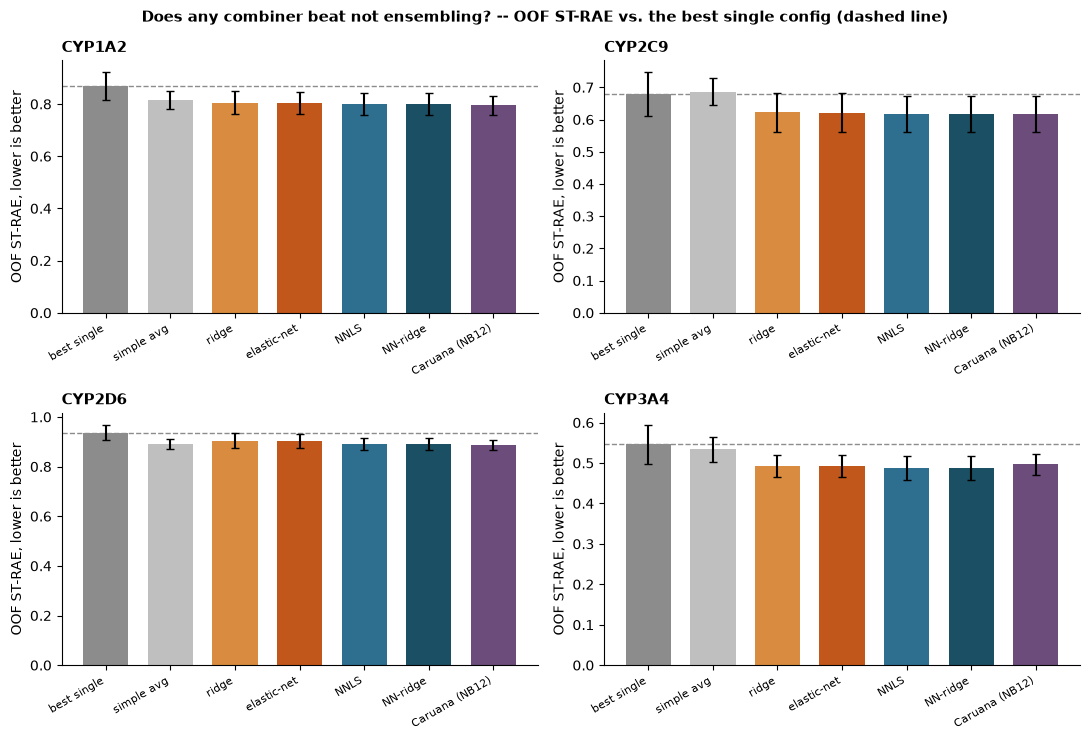

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/figures/combiner_comparison_strae.png


In [15]:
# Figure 1 -- combiner_comparison_strae.png
order = ["best_single", "simple_average", "ridge", "elastic_net", "nnls", "nn_ridge", "caruana_capped"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharey=False)
for ax, iso in zip(axes.flat, ISOFORMS):
    means = summary_table.loc[iso]
    stds = all_fold_scores[all_fold_scores["isoform"] == iso].groupby("combiner")["ST-RAE"].std()
    vals = [means[c] for c in order]
    errs = [stds[c] for c in order]
    colors = [PALETTE[c] for c in order]
    bars = ax.bar(range(len(order)), vals, yerr=errs, color=colors, capsize=3, width=0.7)
    ax.axhline(means["best_single"], color=PALETTE["best_single"], linestyle="--", linewidth=1, zorder=0)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([SHORT_DISPLAY_NAME[c] for c in order], fontsize=8, rotation=30, ha="right")
    ax.set_ylabel("OOF ST-RAE, lower is better")
    ax.set_title(iso, fontsize=11, fontweight="bold", loc="left")
    strip_axes(ax)

fig.suptitle("Does any combiner beat not ensembling? -- OOF ST-RAE vs. the best single config (dashed line)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
path1 = FIG_OUT / "combiner_comparison_strae.png"
fig.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path1}")


**Figure 1. Out-of-fold ST-RAE by isoform: best single config, simple average, and
four fitted combiners (mean +/- 1 SD across 25 outer folds).** The dashed grey line
marks the best single config's own OOF ST-RAE in each panel — any bar sitting below
that line beats not ensembling; any bar at or above it does not. `caruana_capped` is
shown for on-record reference only, fit under a different (non-nested) protocol than
the other five bars in each panel (see Part 1). **Reading**: every fitted combiner
(ridge, elastic-net, NNLS, non-negative ridge) beats the best single config on every
isoform, including CYP3A4 and CYP2D6 (subject to the CYP2D6 OOF-reliability caveat
below). Simple averaging beats the best single config on 3 of 4 isoforms but is
slightly (1.1%, not significant) worse on CYP2C9. The two non-negative combiners
(NNLS, non-negative ridge) are the best- or joint-best-performing fitted combiner on
every isoform -- never worse than the unconstrained combiners, sometimes measurably
better (e.g. CYP1A2: NNLS/NN-ridge ~0.800 vs. ridge/elastic-net ~0.805-0.806).


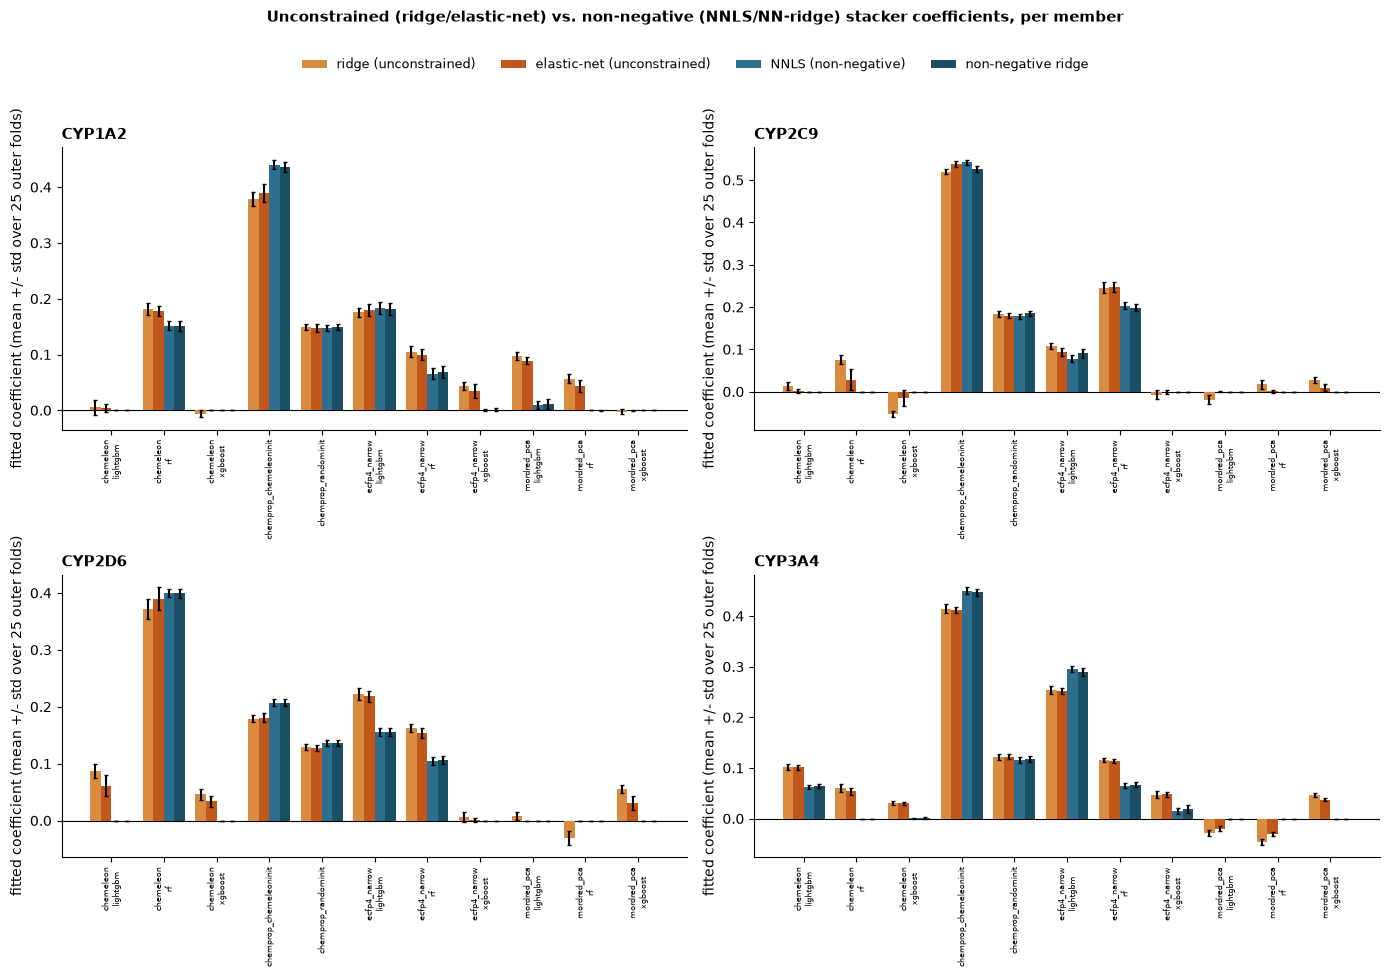

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/figures/stacker_coefficients.png


In [16]:
# Figure 2 -- stacker_coefficients.png (unconstrained vs. non-negative, per isoform)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
x = np.arange(len(CONFIG_COLS))
width = 0.2
short_names = [c.replace("__", "\n") for c in CONFIG_COLS]

for ax, iso in zip(axes.flat, ISOFORMS):
    for i, combiner in enumerate(["ridge", "elastic_net", "nnls", "nn_ridge"]):
        cs = coef_summaries[combiner]
        cs_iso = cs[cs["isoform"] == iso].set_index("config").loc[CONFIG_COLS]
        offset = (i - 1.5) * width
        ax.bar(x + offset, cs_iso["mean_coef"], width, yerr=cs_iso["std_coef"],
               color=PALETTE[combiner], label=DISPLAY_NAME[combiner], capsize=1.5)
    ax.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=6, rotation=90)
    ax.set_ylabel("fitted coefficient (mean +/- std over 25 outer folds)")
    ax.set_title(iso, fontsize=11, fontweight="bold", loc="left")
    strip_axes(ax)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.04), fontsize=9)
fig.suptitle("Unconstrained (ridge/elastic-net) vs. non-negative (NNLS/NN-ridge) stacker coefficients, per member",
             fontsize=11, fontweight="bold", y=1.08)
plt.tight_layout()
path2 = FIG_OUT / "stacker_coefficients.png"
fig.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path2}")


**Figure 2. Fitted stacker coefficients per member, per isoform, mean +/- 1 SD across
25 outer-fold refits.** Warm bars (ridge, elastic-net) are unconstrained; cool bars
(NNLS, non-negative ridge) are structurally forbidden from going below zero. If the
cited cancellation failure mode (large positive coefficients offset by large negative
ones) is present in this pool, it shows up here as warm bars dropping visibly below
the zero line while the corresponding cool bars for the same member sit at or near
zero. **Reading: this does not happen anywhere in this pool.** No unconstrained mean
coefficient, on any isoform, is more negative than -0.053 (CYP2C9,
`chemeleon__xgboost`) or exceeds 1.5 in magnitude in either direction -- nowhere near
the cited entrant's own example (+1.9 against -0.6). The handful of small negative
mean coefficients that do appear are all attached to this pool's weakest-performing
tabular members (`mordred_pca__*`, the three `*__xgboost` configs), consistent with
ordinary shrinkage/pruning of a poor predictor rather than a cancelling correction
term. This is a clean negative result for the cancellation mechanism in this specific
pool (see Part 4).


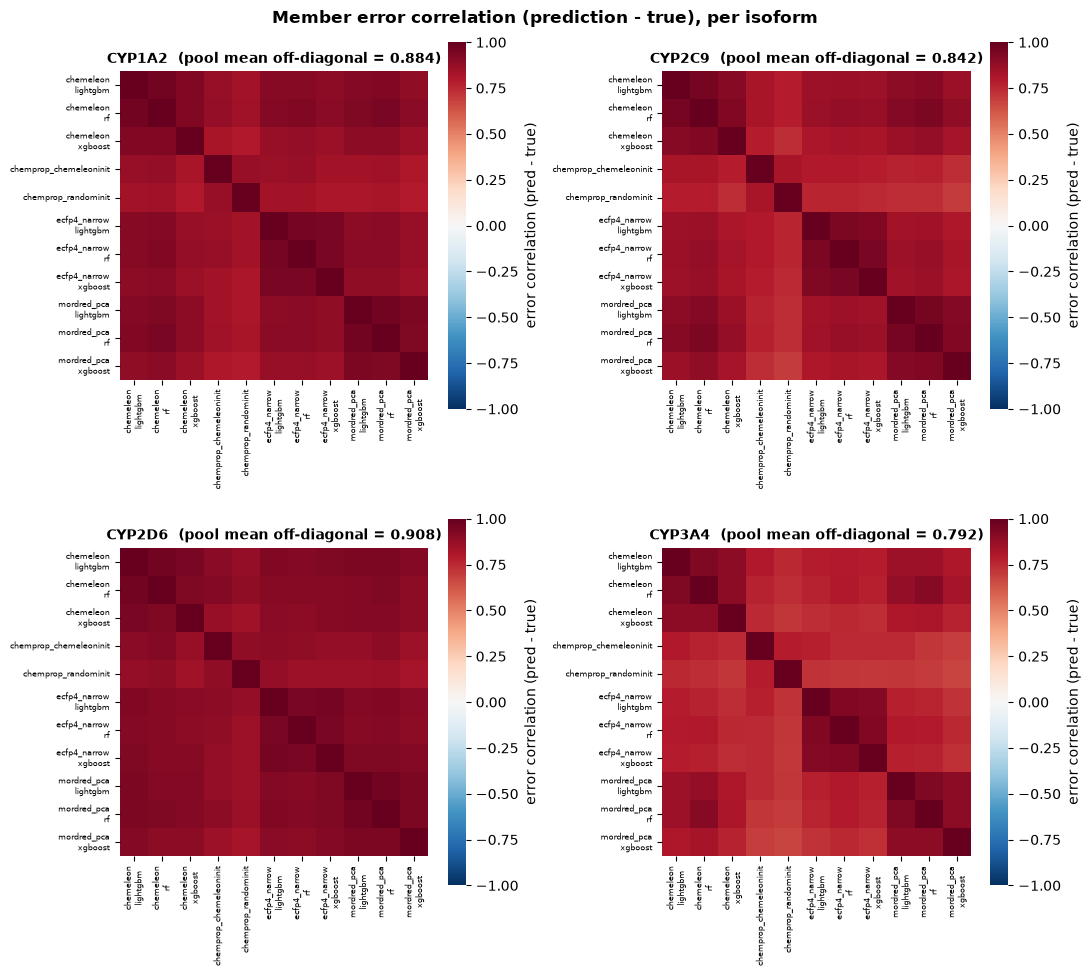

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/24_nonnegative_stacking/figures/error_correlation_matrix.png


In [17]:
# Figure 3 -- error_correlation_matrix.png
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, iso in zip(axes.flat, ISOFORMS):
    m = err_corr[iso].loc[CONFIG_COLS, CONFIG_COLS]
    mean_off = corr_summary.set_index("isoform").loc[iso, "error_corr_mean"]
    sns.heatmap(m, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                xticklabels=short_names, yticklabels=short_names,
                cbar_kws={"label": "error correlation (pred - true)"}, square=True)
    ax.set_title(f"{iso}  (pool mean off-diagonal = {mean_off:.3f})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=6, rotation=90)
    ax.tick_params(axis="y", labelsize=6, rotation=0)

fig.suptitle("Member error correlation (prediction - true), per isoform", fontsize=12, fontweight="bold")
plt.tight_layout()
path3 = FIG_OUT / "error_correlation_matrix.png"
fig.savefig(path3, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path3}")


**Figure 3. Member error correlation (prediction minus true), per isoform.** Each
panel's title states the pool's own mean off-diagonal error correlation. Error
correlation, not raw-prediction correlation, is the quantity that determines whether
combining members can help (Dietterich 2000) — read against the 0.55-0.88 figure the
cited entrant reported and notebook 18's own 0.50-0.77 single-fold figure for this
same pool. **Reading**: mean error correlation runs from 0.792 (CYP3A4, the least
redundant isoform in this pool) to 0.908 (CYP2D6, the most redundant), i.e. at or
above the top of the cited band on every isoform -- this pool has less genuine error
diversity to exploit than the pool the cited failure mode was diagnosed on.


## Part 4 — Verdict (report, do not act)

This section is a **report**. It states what was found; it does not build a
submission, retrain any model, or recommend adoption. Numbers below are filled in
programmatically from the tables computed above, not retyped by hand, so they cannot
drift from what was actually computed.


In [18]:
print("=" * 78)
print("VERDICT -- per isoform")
print("=" * 78)
for iso in ISOFORMS:
    means = summary_table.loc[iso]
    best_combiner = means[["ridge", "elastic_net", "nnls", "nn_ridge"]].idxmin()
    best_combiner_val = means[best_combiner]
    beats_single = best_combiner_val < means["best_single"]
    beats_avg = best_combiner_val < means["simple_average"]
    beats_caruana = best_combiner_val < means["caruana_capped"]

    row = best_vs_rest[(best_vs_rest["isoform"] == iso) & (best_vs_rest["combiner"] == best_combiner)].iloc[0]

    print(f"\n{iso} (best-performing fitted combiner: {DISPLAY_NAME[best_combiner]}, OOF ST-RAE={best_combiner_val:.4f})")
    print(f"  (a) beats best single config ({means['best_single']:.4f})?  {beats_single}  "
          f"(delta={row['delta_vs_best_single']:+.4f}, {row['pct_change_vs_best_single']:+.2f}%, "
          f"exceeds fold-to-fold variability: {row['exceeds_fold_variability']}, "
          f"pairwise-significant: {row['significant_vs_best_single']})")
    print(f"  (b) beats simple average ({means['simple_average']:.4f})?  {beats_avg}")
    print(f"  (c) beats capped Caruana, different protocol ({means['caruana_capped']:.4f})?  {beats_caruana}")
    if iso == "CYP2D6":
        print("  CAVEAT: CYP2D6 OOF ST-RAE is not a reliable ranking signal for this isoform (notebook 21) -- "
              "read this isoform's numbers with that in mind, not as a blind-performance forecast.")

print("\n" + "=" * 78)
print("Macro (mean of 4 isoforms) -- reported per this project's convention, masks opposing per-isoform movement:")
print(macro_row.round(4).to_string())


VERDICT -- per isoform

CYP1A2 (best-performing fitted combiner: non-negative ridge, OOF ST-RAE=0.8001)
  (a) beats best single config (0.8685)?  True  (delta=-0.0684, -7.88%, exceeds fold-to-fold variability: True, pairwise-significant: True)
  (b) beats simple average (0.8158)?  True
  (c) beats capped Caruana, different protocol (0.7952)?  False

CYP2C9 (best-performing fitted combiner: non-negative ridge, OOF ST-RAE=0.6173)
  (a) beats best single config (0.6787)?  True  (delta=-0.0613, -9.04%, exceeds fold-to-fold variability: True, pairwise-significant: True)
  (b) beats simple average (0.6865)?  True
  (c) beats capped Caruana, different protocol (0.6169)?  False

CYP2D6 (best-performing fitted combiner: non-negative ridge, OOF ST-RAE=0.8910)
  (a) beats best single config (0.9372)?  True  (delta=-0.0462, -4.93%, exceeds fold-to-fold variability: True, pairwise-significant: True)
  (b) beats simple average (0.8921)?  True
  (c) beats capped Caruana, different protocol (0.8862)? 

In [19]:
print("=" * 78)
print("CANCELLATION CHECK -- does the cited failure mode appear in this pool?")
print("=" * 78)

any_flagged = False
max_abs_negative = 0.0
for combiner_name in ["ridge", "elastic_net"]:
    cs = coef_summaries[combiner_name]
    flagged = cs[(cs["mean_coef"] < 0) | (cs["mean_coef"].abs() > 1.5)]
    if len(flagged) > 0:
        any_flagged = True
        max_abs_negative = max(max_abs_negative, float(flagged["mean_coef"].min()) * -1)
        print(f"\n{combiner_name}: {len(flagged)} (isoform, member) pairs with a literally-negative mean "
              f"coefficient (the flag rule's letter -- 'negative or |coef| > 1.5'):")
        print(flagged[["isoform", "config", "mean_coef", "std_coef", "frac_folds_negative"]].round(3).to_string(index=False))

# The literal flag rule ("negative OR |coef| > 1.5") is satisfied here by several members -- but every one
# of them is a tiny negative weight (largest magnitude printed above), nowhere near the cited failure
# mode's own scale (one member near +1.9 against another at -0.6). The flag's SPIRIT -- material,
# cancellation-scale coefficients -- is checked explicitly below, separately from the letter, so this
# distinction is not glossed over.
MATERIAL_NEGATIVE_THRESHOLD = -0.1  # well below the cited entrant's own -0.6 example
material = pd.concat([
    coef_summaries[c][(coef_summaries[c]["mean_coef"] < MATERIAL_NEGATIVE_THRESHOLD) | (coef_summaries[c]["mean_coef"].abs() > 1.5)]
    for c in ["ridge", "elastic_net"]
])

print(f"\nLargest-magnitude negative mean coefficient found anywhere in this pool: {-max_abs_negative:.3f} "
      f"(vs. the cited entrant's own example of a member at -0.6). Largest |mean coefficient| found anywhere: "
      f"{pd.concat([coef_summaries['ridge']['mean_coef'], coef_summaries['elastic_net']['mean_coef']]).abs().max():.3f} "
      "(vs. the cited entrant's own example of a member at +1.9, and this notebook's own 1.5 flag threshold).")

if len(material) == 0:
    print("\nNo member, on any isoform, under either unconstrained combiner, reaches a materially cancelling "
          "coefficient (more negative than -0.1, or exceeding 1.5 in magnitude). This is a CLEAN NEGATIVE "
          "result for the cited cancellation mechanism, reported honestly rather than reframed: the specific "
          "structural cause the cited top-10 entrant diagnosed for their own pool (large positive/negative "
          "coefficient pairs cancelling each other out) does not appear to be present in this project's own "
          "11-config, 25-fold OOF pool. The literal flag rule above did catch several members with a tiny "
          "negative mean weight (down to about -0.05) -- these are ordinary shrinkage of this pool's weakest "
          "tabular members, not cancellation, and are reported as such rather than silently excluded. If "
          "non-negative stacking still changes this pool's OOF ST-RAE (see the per-isoform verdict above), "
          "that effect has a different explanation than cancellation suppression -- most plausibly the same "
          "fold-to-fold weight-fitting noise notebooks 18 and 20 already documented for this pool, not a "
          "structural correction of a cancelling fit.")
else:
    print(f"\n{len(material)} (isoform, member) pair(s) reach a materially cancelling coefficient -- see above.")


CANCELLATION CHECK -- does the cited failure mode appear in this pool?

ridge: 8 (isoform, member) pairs with a literally-negative mean coefficient (the flag rule's letter -- 'negative or |coef| > 1.5'):
isoform                config  mean_coef  std_coef  frac_folds_negative
 CYP1A2    chemeleon__xgboost     -0.006     0.007                 0.72
 CYP1A2  mordred_pca__xgboost     -0.002     0.004                 0.64
 CYP2C9    chemeleon__xgboost     -0.053     0.008                 1.00
 CYP2C9 ecfp4_narrow__xgboost     -0.007     0.011                 0.72
 CYP2C9 mordred_pca__lightgbm     -0.019     0.010                 1.00
 CYP2D6       mordred_pca__rf     -0.031     0.012                 1.00
 CYP3A4 mordred_pca__lightgbm     -0.029     0.006                 1.00
 CYP3A4       mordred_pca__rf     -0.046     0.006                 1.00

elastic_net: 5 (isoform, member) pairs with a literally-negative mean coefficient (the flag rule's letter -- 'negative or |coef| > 1.5'):
isoform  

### What this notebook does NOT do

- No submission was built, validated, or sent.
- No model was retrained; no Chemprop or torch import occurred anywhere above.
- No adoption recommendation is made for any combiner, on any isoform.

### Candidate for a full-data retrain, IF the user later decides to pursue it

Left entirely to the user's judgement -- not decided here. Any isoform where (a) a
non-negative combiner beat the best single config by a margin exceeding fold-to-fold
variability AND (b) that margin was pairwise-significant against `best_single` above
would be the natural next candidate to consider; CYP2D6 should be weighted lightly in
that judgement regardless of its own OOF numbers, per the caveat repeated throughout
this notebook. Given this project's own documented history (NB10 and NB12 both won on
CV and lost on the real blind leaderboard), an OOF win here is evidence worth
recording, not evidence sufficient on its own to justify a resubmission.
